In [1]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import joblib

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
import zipfile
import os

# Unzip the file if 'train.csv' is not directly available
if not os.path.exists('train.csv') and os.path.exists('titanic.zip'):
    with zipfile.ZipFile('titanic.zip', 'r') as zip_ref:
        zip_ref.extractall('.')
    print("titanic.zip extracted successfully!")

df = pd.read_csv("train.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

titanic.zip extracted successfully!
Dataset loaded successfully!
Shape: (891, 12)


In [3]:
df = pd.read_csv("train.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (891, 12)


In [9]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [6]:
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

In [7]:
df["IsAlone"] = (df["FamilySize"] == 1).astype(int)

In [8]:
df[[
    "SibSp",
    "Parch",
    "FamilySize",
    "IsAlone"
]].head()

,SibSp,Parch,FamilySize,IsAlone
0,1,0,2,0
1,1,0,2,0
2,0,0,1,1
3,1,0,2,0
4,0,0,1,1


In [9]:
y = df["Survived"]

In [10]:
X = df[
    [
        "Pclass",
        "Sex",
        "Age",
        "SibSp",
        "Parch",
        "Fare",
        "Embarked",
        "FamilySize",
        "IsAlone"
    ]
]

In [11]:
print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

Features:
['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'FamilySize', 'IsAlone']

Target:
Survived


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 712
Testing samples: 179


In [13]:
numeric_features = [
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "FamilySize",
    "IsAlone"
]

In [14]:
categorical_features = [
    "Pclass",
    "Sex",
    "Embarked"
]

In [15]:
numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

In [16]:
categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(handle_unknown="ignore")
        )
    ]
)

In [17]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numeric_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

In [18]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numeric_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

In [20]:
model_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                               ('classifier', LogisticRegression(random_state=42))])

model_pipeline.fit(
    X_train,
    y_train
)

print("Model trained successfully!")

Model trained successfully!


In [21]:
y_pred = model_pipeline.predict(X_test)

In [22]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.8156


In [23]:
precision = precision_score(
    y_test,
    y_pred
)

print(f"Precision: {precision:.4f}")

Precision: 0.8103


In [24]:
recall = recall_score(
    y_test,
    y_pred
)

print(f"Recall: {recall:.4f}")

Recall: 0.6812


In [25]:
f1 = f1_score(
    y_test,
    y_pred
)

print(f"F1 Score: {f1:.4f}")

F1 Score: 0.7402


In [26]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.82      0.90      0.86       110
           1       0.81      0.68      0.74        69

    accuracy                           0.82       179
   macro avg       0.81      0.79      0.80       179
weighted avg       0.82      0.82      0.81       179



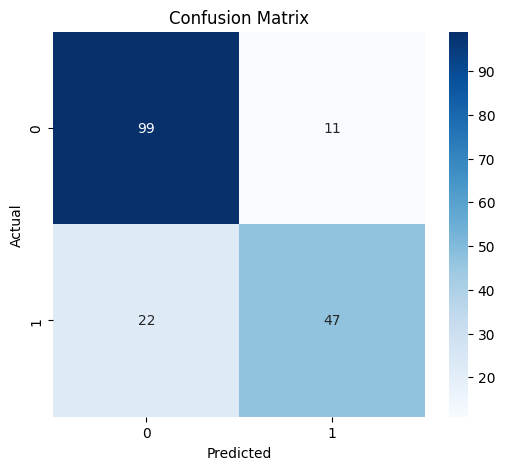

In [27]:
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [28]:
results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

results.head(10)

,Actual,Predicted
0,0,0
1,0,0
2,1,0
3,0,0
4,1,1
5,1,1
6,1,1
7,0,0
8,0,0
9,0,0


In [29]:
joblib.dump(
    model_pipeline,
    "titanic_model.pkl"
)

print("Titanic model saved successfully!")

Titanic model saved successfully!


In [30]:
import os

if os.path.exists("titanic_model.pkl"):
    print("✅ titanic_model.pkl exists")
else:
    print("❌ Model file not found")

✅ titanic_model.pkl exists


In [31]:
loaded_model = joblib.load(
    "titanic_model.pkl"
)

print("✅ Model loaded successfully!")

✅ Model loaded successfully!


In [32]:
new_passenger = pd.DataFrame({
    "Pclass": [1],
    "Sex": ["female"],
    "Age": [25],
    "SibSp": [0],
    "Parch": [0],
    "Fare": [80],
    "Embarked": ["C"],
    "FamilySize": [1],
    "IsAlone": [1]
})

In [33]:
prediction = loaded_model.predict(
    new_passenger
)

print("Prediction:", prediction[0])
if prediction[0] == 1:
    print("Passenger is predicted to SURVIVE.")
else:
    print("Passenger is predicted NOT to survive.")

Prediction: 1
Passenger is predicted to SURVIVE.


In [34]:
probability = loaded_model.predict_proba(
    new_passenger
)

print("Probability of not surviving:", probability[0][0])
print("Probability of surviving:", probability[0][1])

Probability of not surviving: 0.056238039098933656
Probability of surviving: 0.9437619609010663


In [35]:
from google.colab import files

files.download("titanic_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [37]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 84.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 91.3 MB/s eta 0:00:00


In [38]:
import streamlit as st
import pandas as pd
import joblib


# ==================================================
# PAGE CONFIGURATION
# ==================================================

st.set_page_config(
    page_title="Titanic Survival Predictor",
    page_icon="🚢",
    layout="centered"
)


# ==================================================
# LOAD MODEL
# ==================================================

@st.cache_resource
def load_model():
    return joblib.load("titanic_model.pkl")


model = load_model()


# ==================================================
# TITLE
# ==================================================

st.title("🚢 Titanic Survival Predictor")

st.write(
    """
    This application uses a Machine Learning model to
    predict whether a Titanic passenger is likely to survive.
    """
)


st.divider()


# ==================================================
# INPUT SECTION
# ==================================================

st.header("👤 Passenger Information")


# Passenger Class

pclass = st.selectbox(
    "Passenger Class",
    options=[1, 2, 3],
    help="1 = First Class, 2 = Second Class, 3 = Third Class"
)


# Sex

sex = st.selectbox(
    "Sex",
    options=["male", "female"]
)


# Age

age = st.number_input(
    "Age",
    min_value=0.0,
    max_value=100.0,
    value=30.0,
    step=1.0
)


# Siblings / Spouses

sibsp = st.number_input(
    "Number of Siblings / Spouses Aboard",
    min_value=0,
    max_value=10,
    value=0,
    step=1
)


# Parents / Children

parch = st.number_input(
    "Number of Parents / Children Aboard",
    min_value=0,
    max_value=10,
    value=0,
    step=1
)


# Fare

fare = st.number_input(
    "Fare",
    min_value=0.0,
    max_value=600.0,
    value=30.0,
    step=1.0
)


# Embarked

embarked = st.selectbox(
    "Port of Embarkation",
    options=["S", "C", "Q"],
    help="S = Southampton, C = Cherbourg, Q = Queenstown"
)


# ==================================================
# FEATURE ENGINEERING
# ==================================================

family_size = sibsp + parch + 1

is_alone = 1 if family_size == 1 else 0


# ==================================================
# DISPLAY CALCULATED FEATURES
# ==================================================

st.subheader("📊 Calculated Features")

col1, col2 = st.columns(2)


with col1:

    st.metric(
        "Family Size",
        family_size
    )


with col2:

    st.metric(
        "Travelling Alone",
        "Yes" if is_alone == 1 else "No"
    )


st.divider()


# ==================================================
# PREDICTION BUTTON
# ==================================================

predict_button = st.button(
    "🔮 Predict Survival",
    use_container_width=True
)


# ==================================================
# PREDICTION
# ==================================================

if predict_button:

    # Create DataFrame
    input_data = pd.DataFrame({
        "Pclass": [pclass],
        "Sex": [sex],
        "Age": [age],
        "SibSp": [sibsp],
        "Parch": [parch],
        "Fare": [fare],
        "Embarked": [embarked],
        "FamilySize": [family_size],
        "IsAlone": [is_alone]
    })


    # Make prediction
    prediction = model.predict(
        input_data
    )[0]


    # Get probability
    probability = model.predict_proba(
        input_data
    )[0][1]


    # ==================================================
    # DISPLAY RESULT
    # ==================================================

    st.divider()

    st.header("🎯 Prediction Result")


    if prediction == 1:

        st.success(
            "🎉 The passenger is predicted to SURVIVE."
        )

    else:

        st.error(
            "⚠️ The passenger is predicted NOT to survive."
        )


    # Probability

    st.metric(
        "Estimated Survival Probability",
        f"{probability:.2%}"
    )


    # Progress bar

    st.progress(
        float(probability)
    )


    # ==================================================
    # SHOW INPUT DATA
    # ==================================================

    with st.expander("View Passenger Data"):

        st.dataframe(
            input_data,
            use_container_width=True
        )


# ==================================================
# FOOTER
# ==================================================

st.divider()

st.caption(
    "Titanic Survival Prediction | "
    "Machine Learning + Streamlit"
)

2026-08-28 19:11:03.106 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-28 19:11:03.108 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-28 19:11:03.116 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-28 19:11:03.373 
  command:

    streamlit run /usr/local/lib/python3.13/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-08-28 19:11:03.374 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-28 19:11:03.376 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-28 19:11:03.377 Thread 'MainThread'

DeltaGenerator()